<a href="https://colab.research.google.com/github/ellenyifang2011/sea_level/blob/main/src/linear_reg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Sea Level Project**

In [1]:
import sys
import sklearn
from packaging import version

print("Welcome to the Ocean!")
assert version.parse(sklearn.__version__) >= version.parse("1.0.1")
assert sys.version_info >= (3, 7)

from google.colab import drive
drive.mount('/content/drive')


Welcome to the Ocean!
Mounted at /content/drive


# Get the Data

In [2]:
import os, sys
import pandas as pd

def in_colab() -> bool:
    try:
        import google.colab  # type: ignore
        return True
    except Exception:
        return False

def data_dir() -> str:
    if in_colab():
        # default Colab path after mounting Drive
        return "/content/drive/MyDrive/Data"
    return os.path.abspath("./data")  # local default

def path(*parts) -> str:
    return os.path.join(data_dir(), *parts)

def load_data():
    filename="sl_raw2.csv"
    return pd.read_csv(path(filename))

_rawdata = load_data()

## Take a Quick Look at the Data Structure

In [3]:
_rawdata.info()
_rawdata.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Date                            244 non-null    float64
 1   Sea Level Monthly Mean          244 non-null    float64
 2   Antarctic Ice Melt Rates(mass)  244 non-null    float64
 3   Greenland Ice Melt Rates(mass)  244 non-null    float64
 4   Global Temp Anomaly             244 non-null    float64
 5   El Nino                         244 non-null    float64
 6   AMOC                            196 non-null    float64
 7   CO2                             244 non-null    float64
dtypes: float64(8)
memory usage: 15.4 KB


,Date,Sea Level Monthly Mean,Antarctic Ice Melt Rates(mass),Greenland Ice Melt Rates(mass),Global Temp Anomaly,El Nino,AMOC,CO2
count,244.00000,244.000000,244.000000,244.000000,244.000000,244.000000,196.000000,244.000000
mean,2013.74500,0.083807,-1297.980615,-2934.684836,0.799959,-0.007746,16.982245,398.339303
std,6.91902,0.075083,942.498046,1818.472413,0.244191,0.827929,3.097373,16.276347
min,2002.54000,-0.166000,-2780.900000,-5608.870000,0.260000,-1.640000,8.190000,370.730000
25%,2007.68750,0.037000,-2274.782500,-4758.437500,0.620000,-0.595000,15.265000,384.387500
50%,2013.08000,0.081500,-1171.875000,-3218.780000,0.740000,-0.065000,17.070000,395.660000
75%,2020.31000,0.130000,-401.850000,-1287.797500,0.930000,0.502500,19.135000,413.667500
max,2025.37000,0.295000,82.680000,0.000000,1.480000,2.640000,24.990000,430.510000


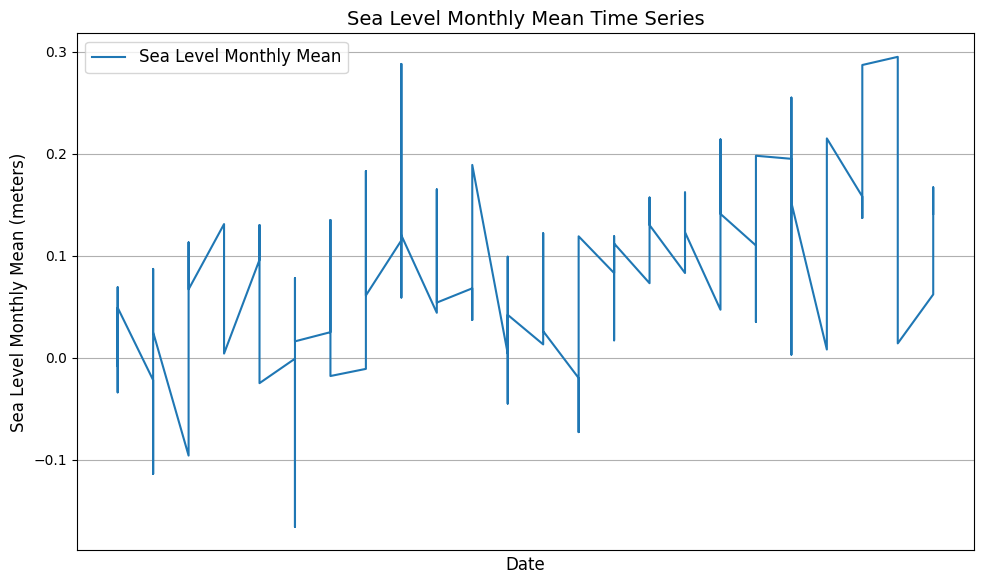

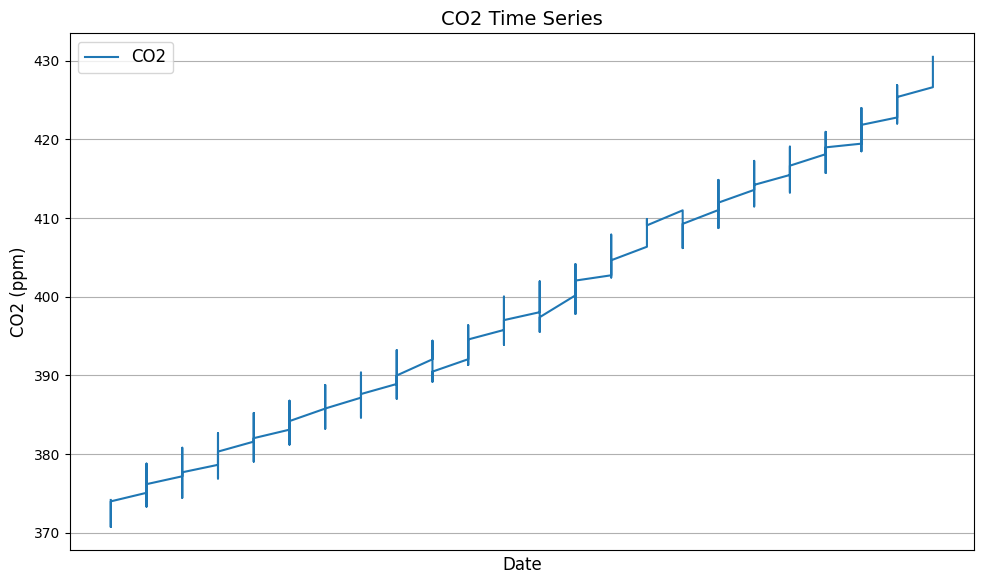

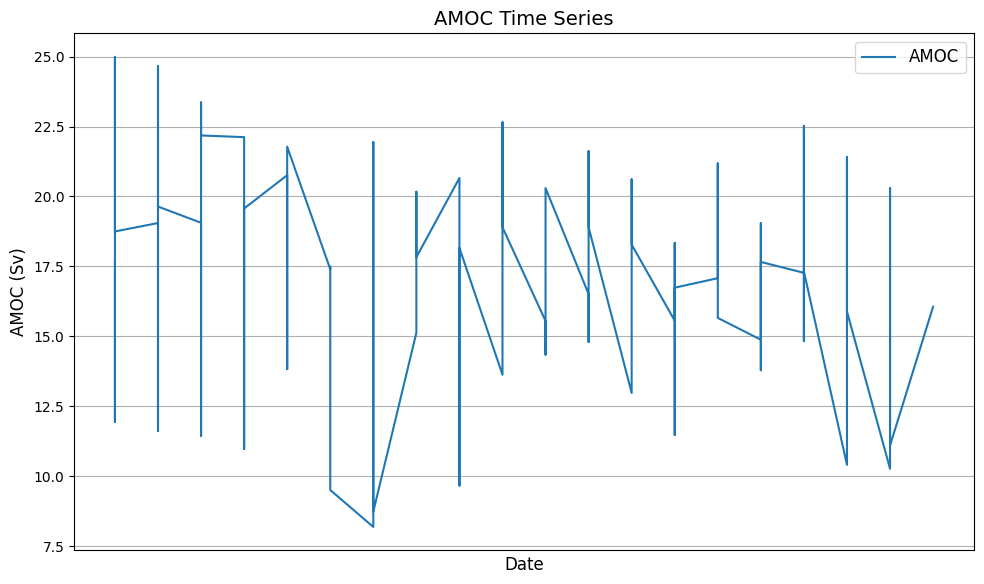

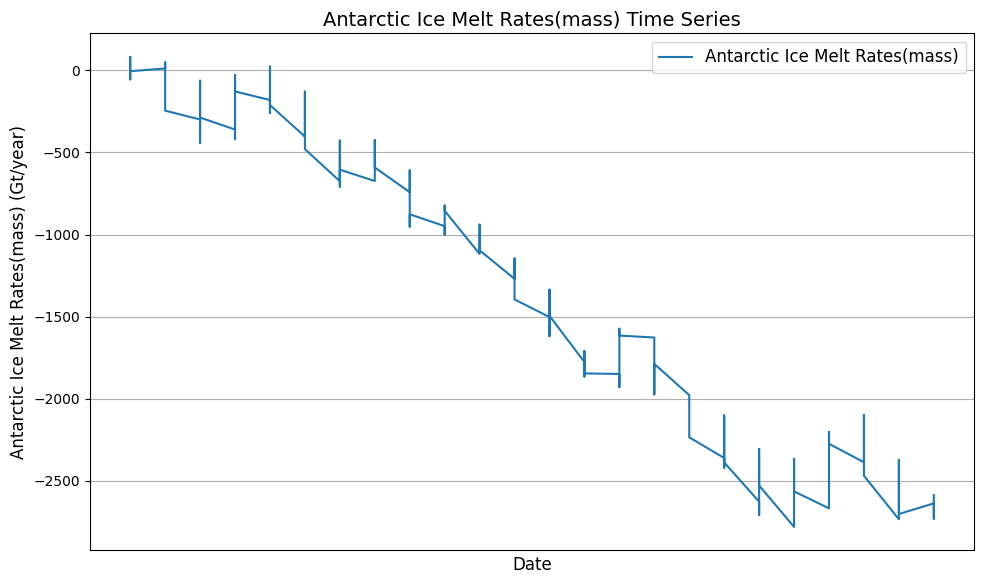

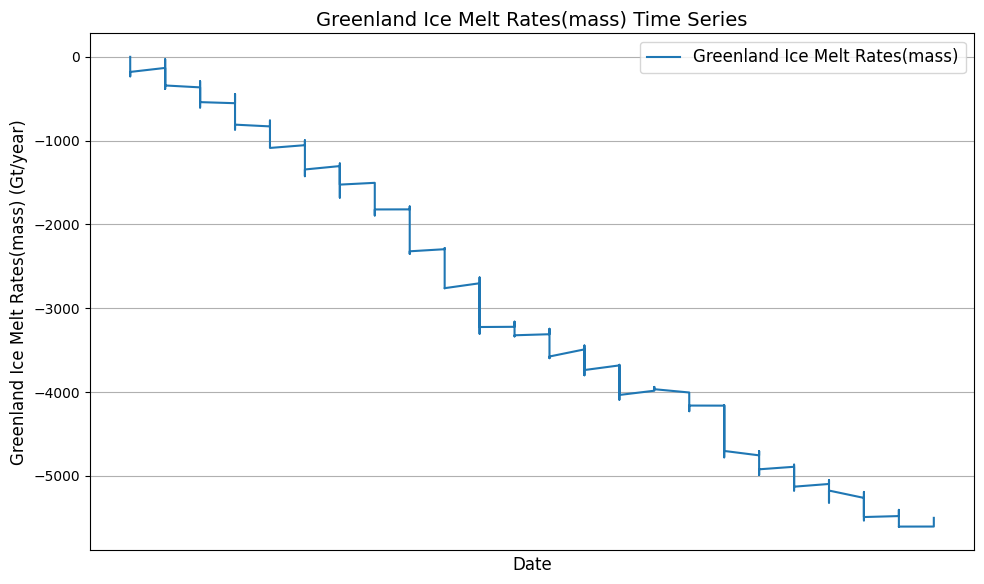

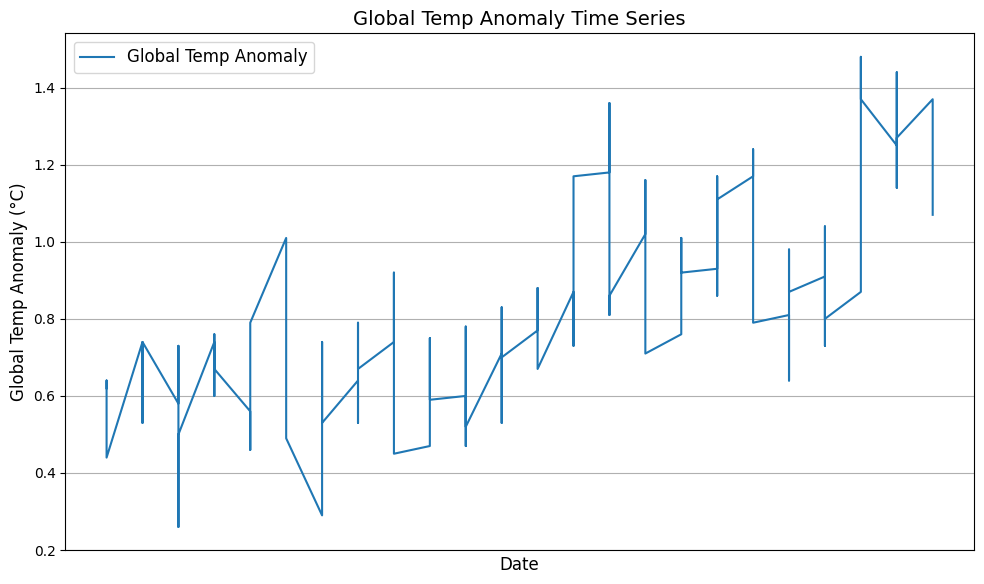

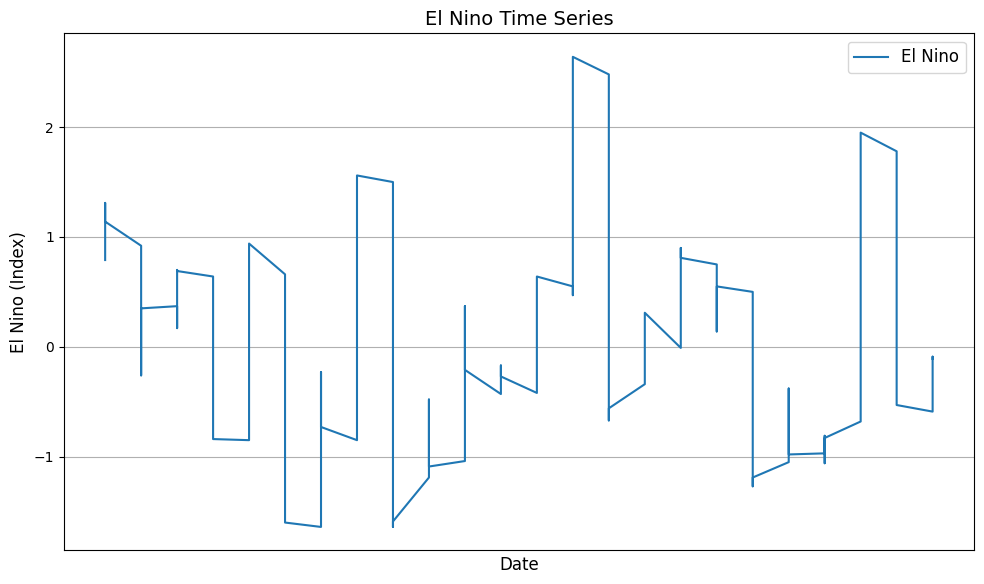

In [15]:
import matplotlib.pyplot as plt
import pandas as pd # Ensure pandas is imported if not already globally available

time_col = "Date"

variables = [
    "Sea Level Monthly Mean",
    "CO2",
    "AMOC",
    "Antarctic Ice Melt Rates(mass)",
    "Greenland Ice Melt Rates(mass)",
    "Global Temp Anomaly",
    "El Nino"
]

variable_units = {
    "Sea Level Monthly Mean": "meters",
    "CO2": "ppm",
    "AMOC": "Sv",
    "Antarctic Ice Melt Rates(mass)": "Gt/year",
    "Greenland Ice Melt Rates(mass)": "Gt/year",
    "Global Temp Anomaly": "°C",
    "El Nino": "Index"
}

# Reload _rawdata to ensure the 'Date' column is present for plotting
data_for_plot = load_data().copy() # Ensure load_data() is accessible

data_for_plot[time_col] = pd.to_datetime(data_for_plot[time_col], format='mixed') # Adjust format for fractional years

plt.rc('font', size=12)
plt.rc('axes', labelsize=12, titlesize=14)
plt.rc('legend', fontsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

for var in variables:
    plt.figure(figsize=(10, 6))
    plt.plot(data_for_plot[time_col], data_for_plot[var], label=var)
    plt.xlabel("Date")
    plt.ylabel(f"{var} ({variable_units.get(var, 'Unit Missing')})")
    plt.title(f"{var} Time Series")
    plt.grid(True)
    plt.legend()
    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()

The following cell is not shown either in the book. It creates the `images` folder (if it doesn't already exist), and it defines the `save_fig()` function which is used through this notebook to save the figures in high-res for the book.

In [4]:
#Drop the Date Column
_rawdata = _rawdata.drop('Date', axis=1)

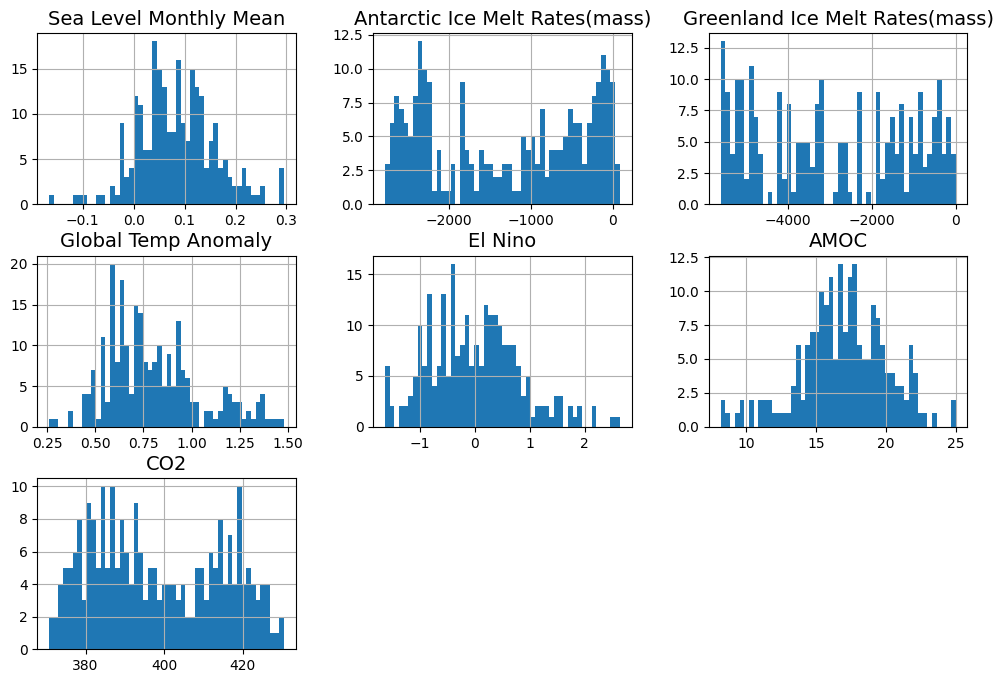

In [5]:
import matplotlib.pyplot as plt

# extra code – the next 5 lines define the default font sizes
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

_rawdata.hist(bins=50, figsize=(12, 8))
#save_fig("attribute_histogram_plots")  # extra code
plt.show()

## Looking for Correlations

Note: since Pandas 2.0.0, the `numeric_only` argument defaults to `False`, so we need to set it explicitly to True to avoid an error.

In [6]:
corr_matrix = _rawdata.corr(numeric_only=True)
corr_matrix["Sea Level Monthly Mean"].sort_values(ascending=False)

,Sea Level Monthly Mean
Sea Level Monthly Mean,1.000000
CO2,0.584535
Global Temp Anomaly,0.530264
El Nino,0.165736
AMOC,-0.237536
Antarctic Ice Melt Rates(mass),-0.544775
Greenland Ice Melt Rates(mass),-0.590641


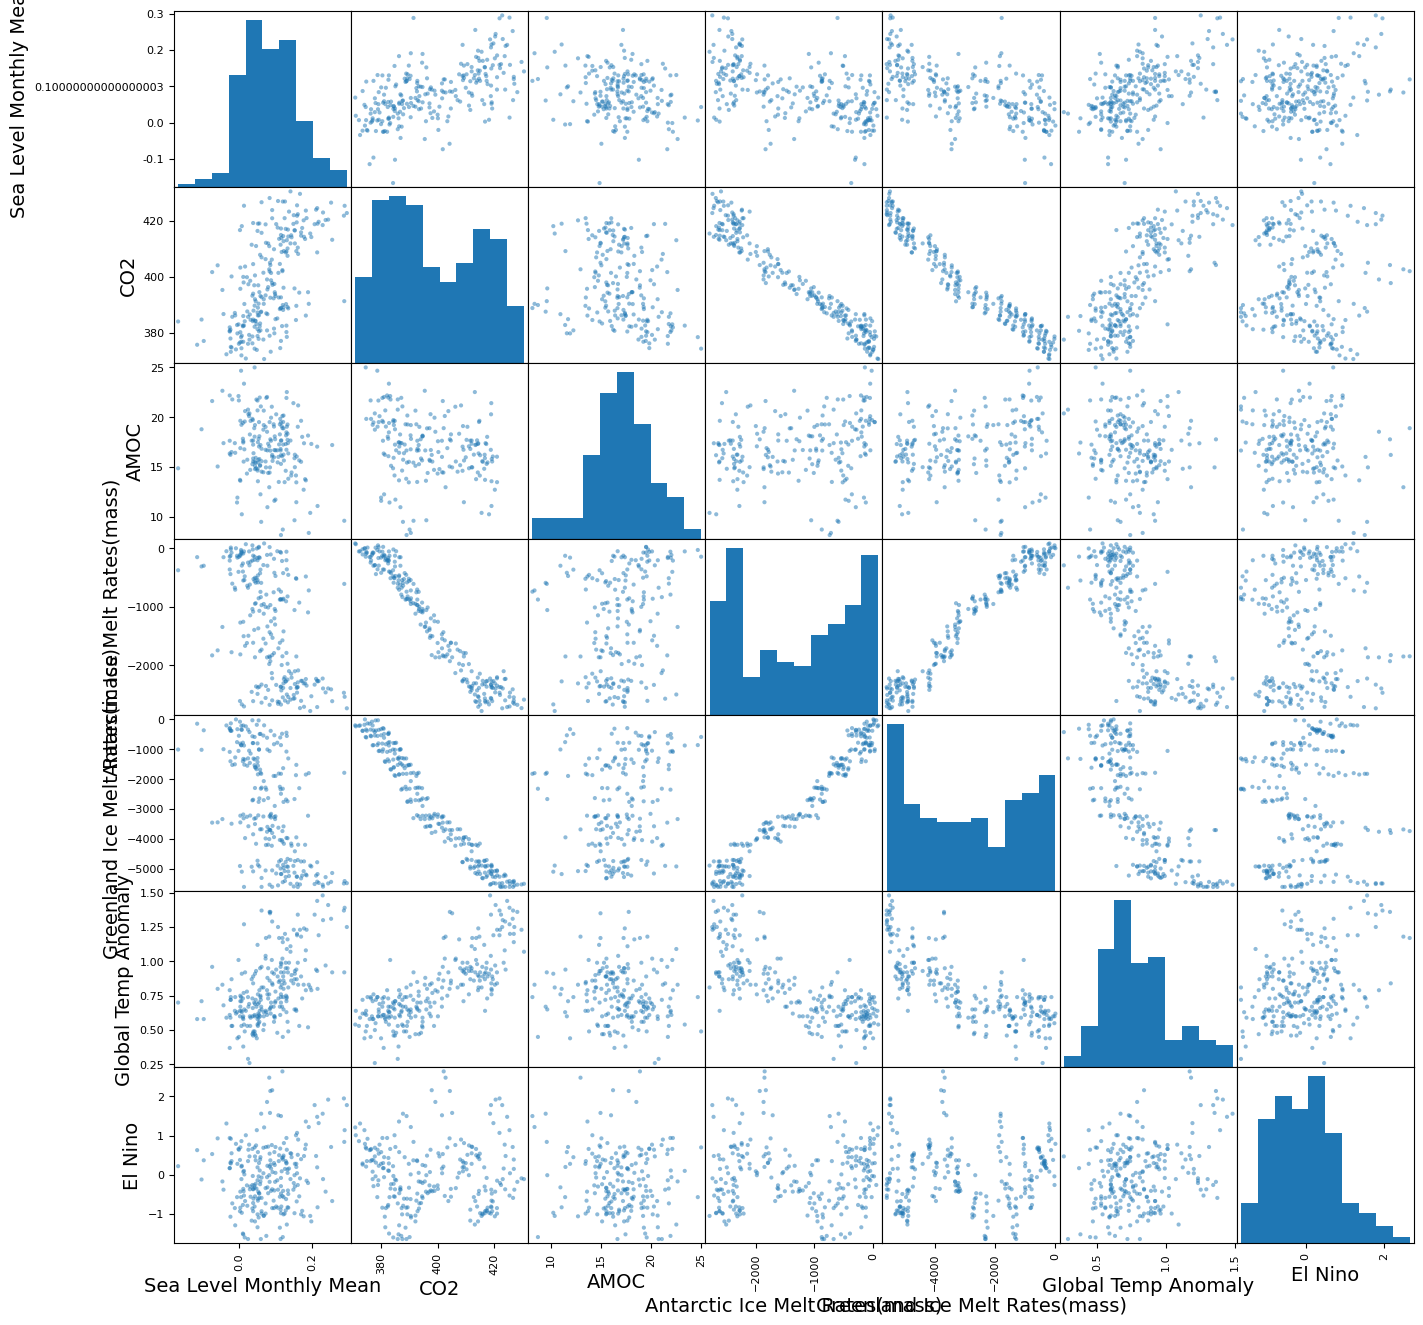

In [7]:
from pandas.plotting import scatter_matrix

attributes = ["Sea Level Monthly Mean","CO2","AMOC","Antarctic Ice Melt Rates(mass)","Greenland Ice Melt Rates(mass)","Global Temp Anomaly",	"El Nino"]
scatter_matrix(_rawdata[attributes], figsize=(16, 16))
#save_fig("scatter_matrix_plot")  # extra code
plt.show()

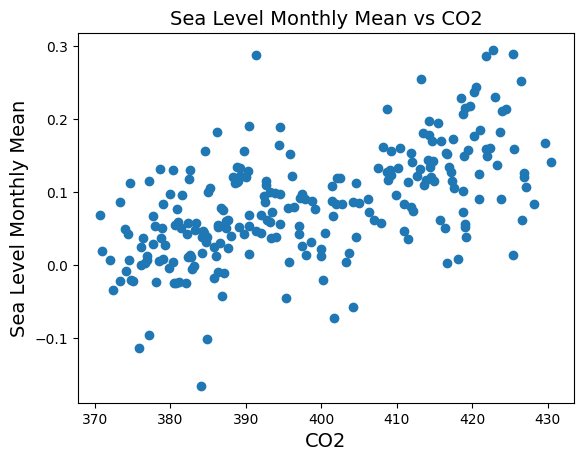

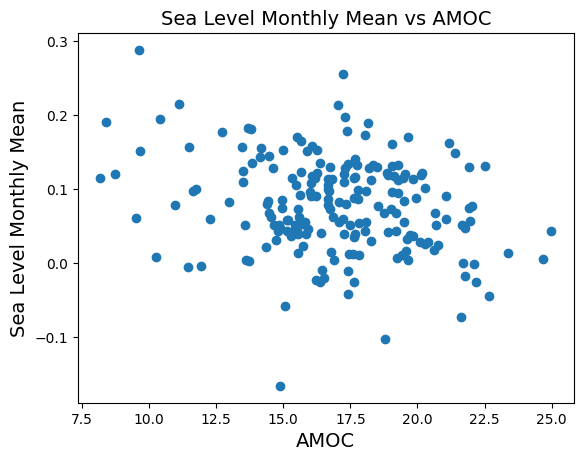

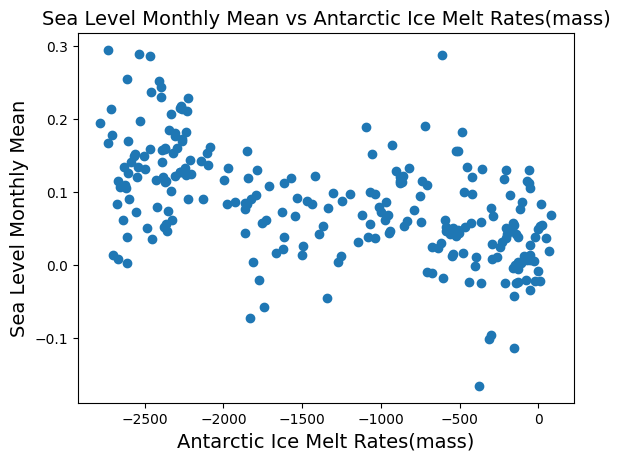

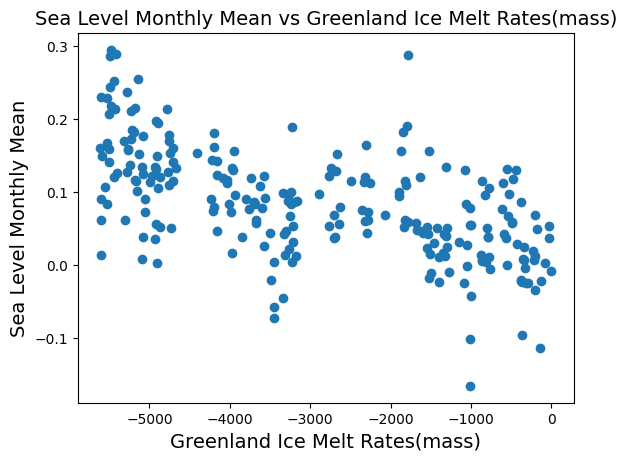

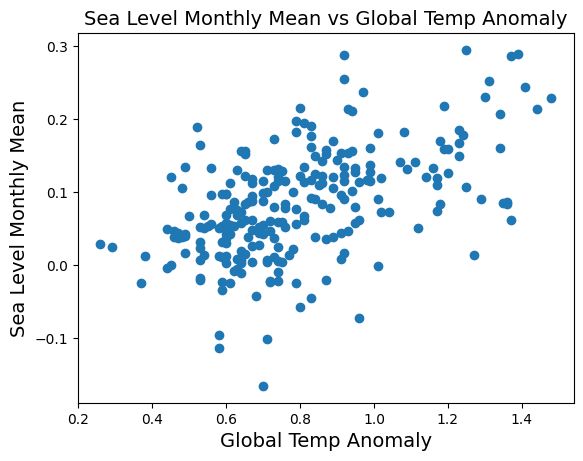

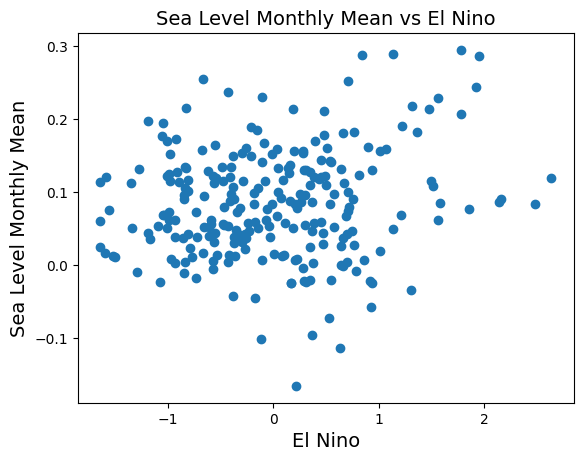

In [9]:
from pandas.plotting import scatter_matrix

target = "Sea Level Monthly Mean"
other_vars = [
    "CO2",
    "AMOC",
    "Antarctic Ice Melt Rates(mass)",
    "Greenland Ice Melt Rates(mass)",
    "Global Temp Anomaly",
    "El Nino"
]

for var in other_vars:
    plt.figure()
    plt.scatter(_rawdata[var], _rawdata[target])
    plt.xlabel(var)
    plt.ylabel(target)
    plt.title(f"{target} vs {var}")
    plt.show()

In [ ]:
# Drop the AMOC since missing data and low correlation

_rawdata = _rawdata.drop('AMOC', axis=1)


## Create Test Set

In [ ]:
from sklearn.model_selection import train_test_split
data_num = _rawdata
train_set, test_set = train_test_split(data_num, test_size=0.2, random_state=42)

rawdata = train_set.drop("Sea Level Monthly Mean", axis=1)
rawdata_labels = train_set["Sea Level Monthly Mean"].copy()

In [ ]:
rawdata.info()

<class 'pandas.core.frame.DataFrame'>
Index: 195 entries, 228 to 102
Data columns (total 5 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Antarctic Ice Melt Rates(mass)  195 non-null    float64
 1   Greenland Ice Melt Rates(mass)  195 non-null    float64
 2   Global Temp Anomaly             195 non-null    float64
 3   El Nino                         195 non-null    float64
 4   CO2                             195 non-null    float64
dtypes: float64(5)
memory usage: 9.1 KB


# Select and Train a Model

## Training and Evaluating on the Training Set

In [ ]:
from sklearn.linear_model import LinearRegression
lin_reg =LinearRegression().fit(rawdata, rawdata_labels)


Let's try the full preprocessing pipeline on a few training instances:

In [ ]:
sl_predictions = lin_reg.predict(rawdata)
sl_predictions[:5]  # -2 = rounded to the nearest hundred

array([0.17542929, 0.14486879, 0.03636479, 0.10150726, 0.0838136 ])

Compare against the actual values:

In [ ]:
rawdata_labels.iloc[:5].values

array([0.214, 0.091, 0.112, 0.047, 0.052])

In [ ]:
# extra code – computes the error ratios discussed in the book
error_ratios = sl_predictions[:5] / rawdata_labels.iloc[:5].values - 1
print(", ".join([f"{100 * ratio:.1f}%" for ratio in error_ratios]))

-18.0%, 59.2%, -67.5%, 116.0%, 61.2%


**Warning**: In recent versions of Scikit-Learn, you must use `root_mean_squared_error(labels, predictions)` to compute the RMSE, instead of `mean_squared_error(labels, predictions, squared=False)`. The following `try`/`except` block tries to import `root_mean_squared_error`, and if it fails it just defines it.

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

def root_mean_squared_error(labels, predictions):
    return mean_squared_error(labels, predictions)

lin_rmse = root_mean_squared_error(rawdata_labels, sl_predictions)
print("lin_rmse=",lin_rmse)
mae = mean_absolute_error(rawdata_labels,sl_predictions)
print("mae=",mae)

lin_rmse= 0.003440378283273107
mae= 0.04429991327865298


In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))
tree_reg.fit(rawdata, rawdata_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('knnimputer',
                                                              KNNImputer(n_neighbors=2,
                                                                         weights='distance')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[])),
                ('decisiontreeregressor',
                 DecisionTreeRegressor(random_state=42))])

In [ ]:
housing_predictions = tree_reg.predict(rawdata)
tree_rmse = root_mean_squared_error(rawdata_labels, sl_predictions)
tree_rmse

## Better Evaluation Using Cross-Validation

In [ ]:
from sklearn.model_selection import cross_val_score

tree_rmses = -cross_val_score(tree_reg, rawdata, rawdata_labels,
                              scoring="neg_root_mean_squared_error", cv=10)

In [ ]:
pd.Series(tree_rmses).describe()

In [ ]:
# extra code – computes the error stats for the linear model
lin_rmses = -cross_val_score(lin_reg, rawdata, rawdata_labels,
                              scoring="neg_root_mean_squared_error", cv=10)
pd.Series(lin_rmses).describe()

**Warning:** the following cell may take a few minutes to run:

In [ ]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = make_pipeline(preprocessing,
                           RandomForestRegressor(random_state=42))
forest_rmses = -cross_val_score(forest_reg, rawdata, rawdata_labels,
                                scoring="neg_root_mean_squared_error", cv=10)

In [ ]:
pd.Series(forest_rmses).describe()

Let's compare this RMSE measured using cross-validation (the "validation error") with the RMSE measured on the training set (the "training error"):

In [ ]:
forest_reg.fit(rawdata, rawdata_labels)
housing_predictions = forest_reg.predict(rawdata)
forest_rmse = root_mean_squared_error(rawdata_labels, sl_predictions)
forest_rmse

The training error is much lower than the validation error, which usually means that the model has overfit the training set. Another possible explanation may be that there's a mismatch between the training data and the validation data, but it's not the case here, since both came from the same dataset that we shuffled and split in two parts.